# Clinician spike annotation review

Compare saved GUI annotations against pipeline ground truth in `clip_shuffle_key.csv`.

**Ground truth**
- **spike / midline:** `best_channel_1` (SpikeNet2 localization)
- **no_spike:** no spike channel should be marked

**Clinician response** (each `*.edf.json`)
- `"label": "marked"` on a channel → chosen spike location
- `"label": "no_spike"` → no visible spike

**Scoring**
| Clip type | Correct | Wrong |
|-----------|---------|-------|
| spike / midline | exactly one marked channel equals `best_channel_1` | wrong channel, no mark, multiple marks, or no_spike flag |
| no_spike | no marked channels | any marked channel |

In [15]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

# --- paths (edit if needed) ---
REPO = Path(r"C:\Users\ryanc\Downloads\Conrad_Lab\progress_sheet\Carlos_GUI")
ANNOTATIONS_DIR = Path(r"C:\Users\ryanc\Downloads\ryan_spike_annotations (1)\ryan_spike_annotations")
SHUFFLE_KEY_CSV = REPO / "clip_edfs_preprocessed" / "clip_shuffle_key.csv"
OUTPUT_CSV = REPO / "clinician_annotation_scores.csv"

assert ANNOTATIONS_DIR.is_dir(), f"Missing annotations folder: {ANNOTATIONS_DIR}"
assert SHUFFLE_KEY_CSV.is_file(), f"Missing shuffle key: {SHUFFLE_KEY_CSV}"

In [16]:
def load_annotation(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def parse_annotation(payload: dict) -> tuple[list[str], bool]:
    """Return (marked_channels, flagged_no_spike)."""
    marked: list[str] = []
    no_spike = False
    for ann in payload.get("channel_annotations", []):
        label = (ann.get("label") or "").strip().lower()
        channel = (ann.get("channel") or "").strip()
        if label == "marked" and channel:
            marked.append(channel)
        elif label == "no_spike":
            no_spike = True
    return marked, no_spike


def score_clip(
    clip_type: str,
    ground_truth_channel: str,
    marked_channels: list[str],
    flagged_no_spike: bool,
) -> tuple[str, str]:
    """Return (verdict, reason) where verdict is correct | wrong | missing."""
    ct = (clip_type or "").strip().lower()
    gt = (ground_truth_channel or "").strip()

    if ct == "no_spike":
        if marked_channels:
            return "wrong", f"marked {marked_channels} on no_spike clip"
        return "correct", "no channel marked"

    if ct in {"spike", "midline"}:
        if flagged_no_spike:
            return "wrong", "flagged no_spike on spike/midline clip"
        if not marked_channels:
            return "wrong", "no channel marked"
        if len(marked_channels) > 1:
            return "wrong", f"multiple channels marked: {marked_channels}"
        if marked_channels[0] == gt:
            return "correct", f"matches best_channel_1 ({gt})"
        return "wrong", f"marked {marked_channels[0]} != best_channel_1 ({gt})"

    return "wrong", f"unknown clip_type: {clip_type!r}"

In [17]:
key_df = pd.read_csv(SHUFFLE_KEY_CSV)
annotation_paths = {
    p.name.removesuffix(".json"): p
    for p in ANNOTATIONS_DIR.glob("*.json")
}

rows: list[dict] = []
for _, row in key_df.iterrows():
    output_name = str(row["output_name"]).strip()
    clip_id = output_name.removesuffix(".edf")
    ann_path = annotation_paths.get(output_name) or annotation_paths.get(f"{clip_id}.edf")

    base = {
        "review_order": row.get("review_order"),
        "output_name": output_name,
        "clip_type": row.get("clip_type"),
        "ieeg_file_name": row.get("ieeg_file_name"),
        "timestamp_sec": row.get("timestamp_sec"),
        "ground_truth_channel": row.get("best_channel_1"),
        "localized_channel": row.get("localized_channel"),
        "spikenet2_probability": row.get("spikenet2_probability"),
    }

    if ann_path is None:
        rows.append({**base, "verdict": "missing", "reason": "no annotation file", "marked_channels": None, "flagged_no_spike": None})
        continue

    payload = load_annotation(ann_path)
    marked, no_spike = parse_annotation(payload)
    verdict, reason = score_clip(
        str(row.get("clip_type", "")),
        str(row.get("best_channel_1", "")),
        marked,
        no_spike,
    )
    rows.append({
        **base,
        "verdict": verdict,
        "reason": reason,
        "marked_channels": ", ".join(marked) if marked else "",
        "flagged_no_spike": no_spike,
        "annotation_file": ann_path.name,
        "annotated_at": payload.get("timestamp"),
    })

results = pd.DataFrame(rows)
results["is_correct"] = results["verdict"] == "correct"
results.head(10)

,review_order,output_name,clip_type,ieeg_file_name,timestamp_sec,ground_truth_channel,localized_channel,spikenet2_probability,verdict,reason,marked_channels,flagged_no_spike,annotation_file,annotated_at,is_correct
0,1,EMU2422_Day04_1_81035.0859.edf,spike,EMU2422_Day04_1,81035.085937,Fp1,Fp1,0.818912,wrong,marked T4 != best_channel_1 (Fp1),T4,False,EMU2422_Day04_1_81035.0859.edf.json,2026-06-11T19:28:16,False
1,2,EMU2729_Day03_1_20797.0859.edf,spike,EMU2729_Day03_1,20797.085937,T4,T4,0.861788,wrong,marked F8 != best_channel_1 (T4),F8,False,EMU2729_Day03_1_20797.0859.edf.json,2026-06-11T19:28:27,False
2,3,EMU2519_Day01_1_435.082.edf,spike,EMU2519_Day01_1,435.082031,F3,F3,0.840799,wrong,flagged no_spike on spike/midline clip,,True,EMU2519_Day01_1_435.082.edf.json,2026-06-11T19:28:36,False
3,4,EMU2742_Day02_1_75349.7617.edf,spike,EMU2742_Day02_1,75349.761718,O1,O1,0.863846,wrong,marked F8 != best_channel_1 (O1),F8,False,EMU2742_Day02_1_75349.7617.edf.json,2026-06-11T19:28:43,False
4,5,EMU2609_Day03_1_38147.2852.edf,spike,EMU2609_Day03_1,38147.285156,F7,F7,0.826460,correct,matches best_channel_1 (F7),F7,False,EMU2609_Day03_1_38147.2852.edf.json,2026-06-11T19:28:55,True
5,6,EMU2609_Day04_1_17000.8672.edf,spike,EMU2609_Day04_1,17000.867187,F8,F8,0.842723,correct,matches best_channel_1 (F8),F8,False,EMU2609_Day04_1_17000.8672.edf.json,2026-06-11T19:29:00,True
6,7,EMU2422_Day03_1_10902.8481.edf,no_spike,EMU2422_Day03_1,10902.848077,NaN,no_spike,NaN,wrong,marked ['T4'] on no_spike clip,T4,False,EMU2422_Day03_1_10902.8481.edf.json,2026-06-11T19:29:15,False
7,8,EMU2466_Day03_1_62585.2461.edf,midline,EMU2466_Day03_1,62585.246093,Fz,Fz,0.814028,wrong,marked T4 != best_channel_1 (Fz),T4,False,EMU2466_Day03_1_62585.2461.edf.json,2026-06-11T19:29:21,False
8,9,EMU2422_Day04_1_63816.0391.edf,spike,EMU2422_Day04_1,63816.039062,O1,O1,0.881292,wrong,marked F8 != best_channel_1 (O1),F8,False,EMU2422_Day04_1_63816.0391.edf.json,2026-06-11T19:36:29,False
9,10,EMU1049_Day08_1_79294.5312.edf,spike,EMU1049_Day08_1,79294.531250,C4,C4,0.838456,wrong,marked T4 != best_channel_1 (C4),T4,False,EMU1049_Day08_1_79294.5312.edf.json,2026-06-11T19:36:34,False


In [18]:
summary = (
    results.groupby(["clip_type", "verdict"], dropna=False)
    .size()
    .unstack(fill_value=0)
)
print("Overall accuracy:", f"{results['is_correct'].mean():.1%}", f"({results['is_correct'].sum()}/{len(results)})")
print()
display(summary)

by_type = (
    results.groupby("clip_type")["is_correct"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "n_correct", "count": "n_total", "mean": "accuracy"})
    .sort_values("clip_type")
)
by_type

Overall accuracy: 22.5% (45/200)



verdict,correct,wrong
clip_type,,
midline,0,10
no_spike,25,5
spike,20,140


,n_correct,n_total,accuracy
clip_type,,,
midline,0,10,0.000000
no_spike,25,30,0.833333
spike,20,160,0.125000


In [19]:
correct = results[results["verdict"] == "correct"].sort_values("review_order")
wrong = results[results["verdict"] == "wrong"].sort_values("review_order")
missing = results[results["verdict"] == "missing"]

print(f"Correct: {len(correct)} | Wrong: {len(wrong)} | Missing: {len(missing)}")
print("\n--- Correct clips ---")
display(
    correct[
        [
            "review_order", "output_name", "clip_type",
            "ground_truth_channel", "marked_channels", "reason",
        ]
    ]
)

Correct: 45 | Wrong: 155 | Missing: 0

--- Correct clips ---


,review_order,output_name,clip_type,ground_truth_channel,marked_channels,reason
4,5,EMU2609_Day03_1_38147.2852.edf,spike,F7,F7,matches best_channel_1 (F7)
5,6,EMU2609_Day04_1_17000.8672.edf,spike,F8,F8,matches best_channel_1 (F8)
10,11,EMU2609_Day05_1_77191.3711.edf,spike,F7,F7,matches best_channel_1 (F7)
12,13,EMU2609_Day05_1_33770.8477.edf,spike,F7,F7,matches best_channel_1 (F7)
18,19,EMU2609_Day04_1_5948.1048.edf,no_spike,NaN,,no channel marked
21,22,EMU2422_Day03_1_2307.7218.edf,no_spike,NaN,,no channel marked
25,26,EMU2695_Day01_1_45581.5156.edf,spike,Fp2,Fp2,matches best_channel_1 (Fp2)
27,28,EMU2609_Day03_1_3441.7695.edf,spike,F7,F7,matches best_channel_1 (F7)
29,30,EMU2742_Day03_1_67111.9219.edf,spike,F8,F8,matches best_channel_1 (F8)
30,31,EMU2729_Day03_1_81426.0315.edf,no_spike,NaN,,no channel marked


In [20]:
print("--- Wrong clips ---")
display(
    wrong[
        [
            "review_order", "output_name", "clip_type",
            "ground_truth_channel", "marked_channels",
            "flagged_no_spike", "reason",
        ]
    ]
)

--- Wrong clips ---


,review_order,output_name,clip_type,ground_truth_channel,marked_channels,flagged_no_spike,reason
0,1,EMU2422_Day04_1_81035.0859.edf,spike,Fp1,T4,False,marked T4 != best_channel_1 (Fp1)
1,2,EMU2729_Day03_1_20797.0859.edf,spike,T4,F8,False,marked F8 != best_channel_1 (T4)
2,3,EMU2519_Day01_1_435.082.edf,spike,F3,,True,flagged no_spike on spike/midline clip
3,4,EMU2742_Day02_1_75349.7617.edf,spike,O1,F8,False,marked F8 != best_channel_1 (O1)
6,7,EMU2422_Day03_1_10902.8481.edf,no_spike,NaN,T4,False,marked ['T4'] on no_spike clip
...,...,...,...,...,...,...,...
195,196,EMU2466_Day01_1_10874.8398.edf,spike,P4,F4,False,marked F4 != best_channel_1 (P4)
196,197,EMU2729_Day03_1_62272.6797.edf,spike,T4,F8,False,marked F8 != best_channel_1 (T4)
197,198,EMU2609_Day05_1_32137.3477.edf,midline,Fz,F7,False,marked F7 != best_channel_1 (Fz)
198,199,EMU2609_Day03_1_82879.9022.edf,no_spike,NaN,T4,False,marked ['T4'] on no_spike clip


In [21]:
# Break down wrong answers by reason
wrong_reasons = (
    wrong.groupby(["clip_type", "reason"]).size().reset_index(name="count").sort_values(["clip_type", "count"], ascending=[True, False])
)
wrong_reasons

,clip_type,reason,count
0,midline,flagged no_spike on spike/midline clip,4
2,midline,marked F7 != best_channel_1 (Fz),2
3,midline,marked F8 != best_channel_1 (Fz),2
1,midline,marked C4 != best_channel_1 (Fz),1
4,midline,marked T4 != best_channel_1 (Fz),1
8,no_spike,marked ['T4'] on no_spike clip,2
5,no_spike,marked ['F8'] on no_spike clip,1
6,no_spike,marked ['Fp2'] on no_spike clip,1
7,no_spike,marked ['Fz'] on no_spike clip,1
9,spike,flagged no_spike on spike/midline clip,62


In [22]:
# Optional: also check against localized_channel (often same as best_channel_1)
spike_mid = results[results["clip_type"].isin(["spike", "midline"])].copy()
spike_mid["first_marked"] = spike_mid["marked_channels"].str.split(", ").str[0].fillna("")
spike_mid["matches_localized"] = spike_mid["first_marked"] == spike_mid["localized_channel"].astype(str)
print(
    "Spike/midline marked channel matches localized_channel:",
    f"{spike_mid['matches_localized'].mean():.1%}",
)
spike_mid[["output_name", "localized_channel", "ground_truth_channel", "marked_channels", "matches_localized"]].head(10)

Spike/midline marked channel matches localized_channel: 11.8%


,output_name,localized_channel,ground_truth_channel,marked_channels,matches_localized
0,EMU2422_Day04_1_81035.0859.edf,Fp1,Fp1,T4,False
1,EMU2729_Day03_1_20797.0859.edf,T4,T4,F8,False
2,EMU2519_Day01_1_435.082.edf,F3,F3,,False
3,EMU2742_Day02_1_75349.7617.edf,O1,O1,F8,False
4,EMU2609_Day03_1_38147.2852.edf,F7,F7,F7,True
5,EMU2609_Day04_1_17000.8672.edf,F8,F8,F8,True
7,EMU2466_Day03_1_62585.2461.edf,Fz,Fz,T4,False
8,EMU2422_Day04_1_63816.0391.edf,O1,O1,F8,False
9,EMU1049_Day08_1_79294.5312.edf,C4,C4,T4,False
10,EMU2609_Day05_1_77191.3711.edf,F7,F7,F7,True


In [23]:
results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved full score table -> {OUTPUT_CSV}")

Saved full score table -> C:\Users\ryanc\Downloads\Conrad_Lab\progress_sheet\Carlos_GUI\clinician_annotation_scores.csv


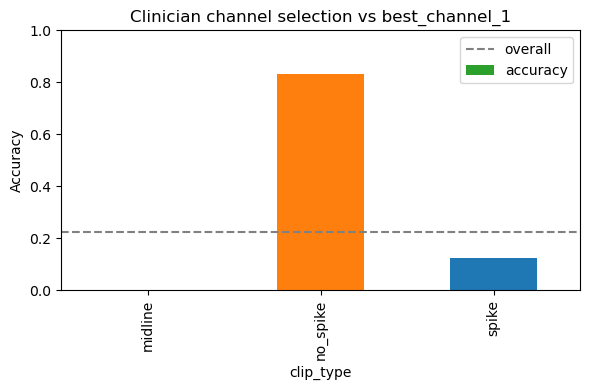

In [25]:
# Optional bar chart
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 4))
    by_type["accuracy"].plot(kind="bar", ax=ax, color=["#2ca02c", "#ff7f0e", "#1f77b4"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Clinician channel selection vs best_channel_1")
    ax.axhline(results["is_correct"].mean(), color="gray", linestyle="--", label="overall")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed; skip chart")

## PPV vs SN2 localization score (`best_prob_1`) — binned

Spike and midline clips only (no_spike excluded). Clips with `best_prob_1 ≥ 0.60` are omitted.

**Bins:** non-overlapping 0.05-wide intervals. Tick **τ = 0.50** is the bin **0.45 ≤ best_prob_1 < 0.50** (all scores *below* 0.50, not including 0.50).

Hypothesis: lower `best_prob_1` → SN2 is more likely on the correct channel. The plot shows whether PPV rises in lower-probability bins.

- **TP:** clinician marked exactly `best_channel_1` (single mark)
- **FP:** any other response
- **PPV = TP / (TP + FP)** within each bin only

In [26]:
import numpy as np

BIN_WIDTH = 0.05
MAX_PROB = 0.60  # only score clips with best_prob_1 < 0.60
BIN_EDGES = np.arange(0.0, MAX_PROB + BIN_WIDTH, BIN_WIDTH)  # 0.00 … 0.60
BIN_LABELS = np.round(BIN_EDGES[1:], 2)  # 0.05, 0.10, …, 0.60 (upper edge of each bin)

loc = results.merge(
    key_df[["output_name", "best_prob_1", "best_prob_2"]],
    on="output_name",
    how="left",
).copy()
loc = loc[loc["clip_type"].isin(["spike", "midline"])].copy()
loc["best_prob_1"] = pd.to_numeric(loc["best_prob_1"], errors="coerce")
loc = loc.dropna(subset=["best_prob_1"])
loc = loc[loc["best_prob_1"] < MAX_PROB].copy()

loc["clinician_tp"] = (
    loc["marked_channels"].str.split(", ").str.len().eq(1)
    & ~loc["flagged_no_spike"].fillna(False)
    & (loc["marked_channels"] == loc["ground_truth_channel"].astype(str))
)

ppv_rows: list[dict] = []
for lo, hi in zip(BIN_EDGES[:-1], BIN_EDGES[1:]):
    cohort = loc[(loc["best_prob_1"] >= lo) & (loc["best_prob_1"] < hi)]
    tp = int(cohort["clinician_tp"].sum())
    fp = int(len(cohort) - tp)
    n = len(cohort)
    ppv = tp / (tp + fp) if (tp + fp) else float("nan")
    ppv_rows.append({
        "bin_upper": float(hi),
        "bin_lower": float(lo),
        "bin_label": f"[{lo:.2f}, {hi:.2f})",
        "n_clips": n,
        "tp": tp,
        "fp": fp,
        "ppv": ppv,
    })

ppv_df = pd.DataFrame(ppv_rows).sort_values("bin_upper", ascending=False).reset_index(drop=True)
ppv_df

,threshold,n_clips,tp,fp,ppv
0,0.60,156,20,136,0.128205
1,0.55,151,19,132,0.125828
2,0.50,141,19,122,0.134752
3,0.45,137,18,119,0.131387
4,0.40,129,18,111,0.139535
5,0.35,117,15,102,0.128205
6,0.30,108,13,95,0.120370
7,0.25,101,13,88,0.128713
8,0.20,89,12,77,0.134831
9,0.15,76,10,66,0.131579


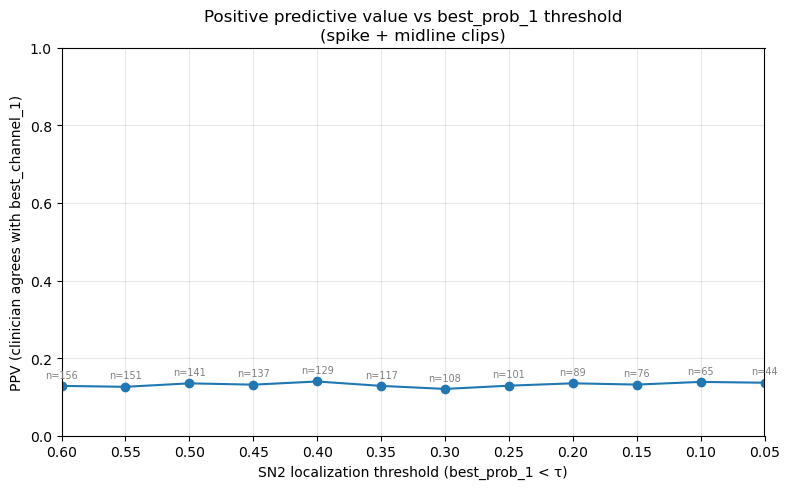

In [27]:
import matplotlib.pyplot as plt

plot_df = ppv_df.dropna(subset=["ppv"]).copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(plot_df["bin_upper"], plot_df["ppv"], marker="o", linewidth=1.5)
ax.set_xlim(0.6, 0.05)
ax.set_xticks(BIN_LABELS)
ax.set_xlabel("best_prob_1 bin upper edge (bin = [upper−0.05, upper))")
ax.set_ylabel("PPV (clinician agrees with best_channel_1)")
ax.set_title("PPV by best_prob_1 bin (spike + midline, best_prob_1 < 0.60)")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

for _, row in plot_df.iterrows():
    ax.annotate(
        f"n={int(row['n_clips'])}",
        (row["bin_upper"], row["ppv"]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=7,
        color="gray",
    )

plt.tight_layout()
plt.show()